In [ ]:
install.packages("sjSDM")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("tidyverse")
install.packages("conflicted")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:

install_sjSDM(version = "gpu")
library(sjSDM)


+ /root/.local/share/r-miniconda/bin/conda install --yes --name r-sjsdm 'python=3.10' -c pytorch

+ /root/.local/share/r-miniconda/bin/conda install --yes --name r-sjsdm -c pytorch 'python=3.10' pytorch torchvision torchaudio 'cudatoolkit=11.8' -c nvidia

✔ Installation complete.




In [ ]:
system("nvidia-smi", intern = TRUE)
system("/root/.local/share/r-miniconda/bin/conda run -n r-sjsdm pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --force-reinstall")

[1] "Fri Feb 20 10:07:53 2026       "                                                            
 [2] "+-----------------------------------------------------------------------------------------+"
 [3] "| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |"
 [4] "+-----------------------------------------+------------------------+----------------------+"
 [5] "| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |"
 [6] "| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |"
 [7] "|                                         |                        |               MIG M. |"
 [8] "|=========================================+========================+======================|"
 [9] "|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |"
[10] "| N/A   44C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |"
[11] "|                                         |                        |                  N/A |"
[12] "+-----------------------------------------+------------------------+----------------------+"
[13] ""                                                                                           
[14] "+-----------------------------------------------------------------------------------------+"
[15] "| Processes:                                                                              |"
[16] "|  GPU   GI   CI              PID   Type   Process name                        GPU Memory |"
[17] "|        ID   ID                                                               Usage      |"
[18] "|=========================================================================================|"
[19] "|  No running processes found                                                             |"
[20] "+-----------------------------------------------------------------------------------------+"

In [ ]:
library(reticulate)
use_condaenv("r-sjsdm", required = TRUE)

torch <- import("torch")
cat("CUDA available:", torch$cuda$is_available(), "\n")

CUDA available: TRUE 


In [ ]:
library(reticulate)
use_condaenv("r-sjsdm", required = TRUE)

torch <- import("torch")
cat("PyTorch version:", torch$`__version__`, "\n")
cat("CUDA available:", torch$cuda$is_available(), "\n")
cat("CUDA version:", torch$version$cuda, "\n")

PyTorch version: 2.5.1 
CUDA available: FALSE 
CUDA version: 


In [ ]:
library(reticulate)
use_condaenv("r-sjsdm", required = TRUE)
library(sjSDM)
library(tidyverse)
library(conflicted)

conflict_prefer("select", "dplyr")

data_calanda_jsdm = readRDS("/content/drive/MyDrive/A_ETH/Calanda_JSDM/Calanda_JSDM_Max_May25/May_2025/data_calanda_jsdm.rds")
X = data_calanda_jsdm$X
Y = data_calanda_jsdm$Y

[conflicted] Removing existing preference.
[conflicted] Will prefer dplyr::select over any other package.


In [ ]:
print(head(X))

                 Longitude    Latitude  altitude      slope summer_temp
0.OID2979453   -0.08082084  0.34235362  1.176136 -0.8658967   -1.347026
1.CID2976369    0.74222815 -0.53878055 -1.294670 -0.5369073    1.310827
1.OID2979971   -1.42208587 -0.77600898  1.348809 -0.1256707   -1.493020
10.CID2979455   0.71174485 -0.57267032 -1.292842 -0.6191547    1.299043
10.OID2979552  -0.32468721  0.37624340  1.449177 -1.2771333   -1.689889
100.CID2980009 -0.17227073 -0.03043391  1.151181 -0.3724127   -1.252925
                      fdd   et.annual soil_depth_mean soil_depth_var
0.OID2979453    0.7553523 -0.76182174      -0.5344032     -0.2788989
1.CID2976369   -0.8312678 -0.22432012      -0.7368230     -0.6329900
1.OID2979971    0.7416647 -0.95894258      -1.1223845     -0.4354803
10.CID2979455  -0.1178321  0.00381125       6.1840063      0.2996950
10.OID2979552   0.7553523 -0.79360671      -1.0452722     -0.6307955
100.CID2980009  0.7553523 -0.57084403      -0.6211546     -0.3617433
             

In [ ]:
print(head(Y))

               Aconitum napellus Agrostis capillaris Agrostis stolonifera
0.OID2979453                   1                   1                    1
1.CID2976369                   0                   0                    0
1.OID2979971                   0                   0                    0
10.CID2979455                  0                   1                    0
10.OID2979552                  0                   0                    0
100.CID2980009                 0                   0                    0
               Alchemilla conjuncta Alchemilla vulgaris Campanula scheuchzeri
0.OID2979453                      1                   1                     1
1.CID2976369                      0                   0                     0
1.OID2979971                      1                   0                     0
10.CID2979455                     0                   0                     0
10.OID2979552                     1                   0                     1
100.CID2980009

In [ ]:
lambda.env = 0.001
alpha.env = 1.0

lambda.sp = 0.002
alpha.sp = 0.2

lambda.bio = 0.001
alpha.bio = 1.0

learning_rate = 0.01
sampling = 10000L
device = "gpu"
iterations = 750L
act = "selu"

In [ ]:
model =
  sjSDM(
  Y = Y,
  env = linear(X,
               formula = ~summer_temp + fdd + et.annual + slope + rocks_cover + trees_cover + shrubs_cover + soil_depth_mean + soil_depth_var + tpi + flowdir + roughness + land_use,
               lambda = lambda.sp, alpha = alpha.sp),
  spatial = DNN(X %>% select(Latitude, Longitude),
                formula = ~0+.,
                activation = act,
                hidden = rep(30, 2),
                bias = FALSE,
                lambda = lambda.sp, alpha = alpha.sp),
  #spatial = linear(data = veg.env, formula = ~0+x*y, lambda = lambda.sp, alpha = alpha.sp),
  biotic = bioticStruct(lambda = lambda.bio, alpha = alpha.bio, df = ncol(Y), reg_on_Cov = FALSE),
  iter = iterations,
  device = device,
  learning_rate = learning_rate,
  sampling = sampling,
  control = sjSDMControl(RMSprop(weight_decay = 0.0),
                         scheduler = 5L,
                         early_stopping_training = 25L,
                         lr_reduce_factor = 0.9),
  se=T
)

In [ ]:

saveRDS(model, file ="/content/drive/MyDrive/A_ETH/Calanda_JSDM/model_sjsdm_calanda_gpu_collab.rds")

Family:  binomial 

LogLik:  -24976.4 
Regularization loss:  4.137532 

Spatial architecture:
Layer_1:	 (2, 30)
Layer_2:	 SELU
Layer_3:	 (30, 30)
Layer_4:	 SELU
Layer_5:	 (30, 363)
Weights :	 11850



                                                             Estimate   Std.Err
Aconitum napellus (Intercept)                               -2.19e+00  4.80e-01
Aconitum napellus summer_temp                               -2.05e-04  3.99e-01
Aconitum napellus fdd                                       -4.33e-05  1.47e-01
Aconitum napellus et.annual                                 -1.24e-01  3.23e-01
Aconitum napellus slope                                     -2.87e-01  2.87e-01
Aconitum napellus rocks_cover                                8.74e-02  1.81e-01
Aconitum napellus trees_cover                               -2.92e-01  4.12e-01
Aconitum napellus shrubs_cover                               2.97e-01  2.80e-01
Aconitum napellus soil_depth_mean                            6.62e-01  3.86e-01

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the sjSDM package.
  Please report the issue at
  <https://github.com/TheoreticalEcology/s-jSDM/issues>.”


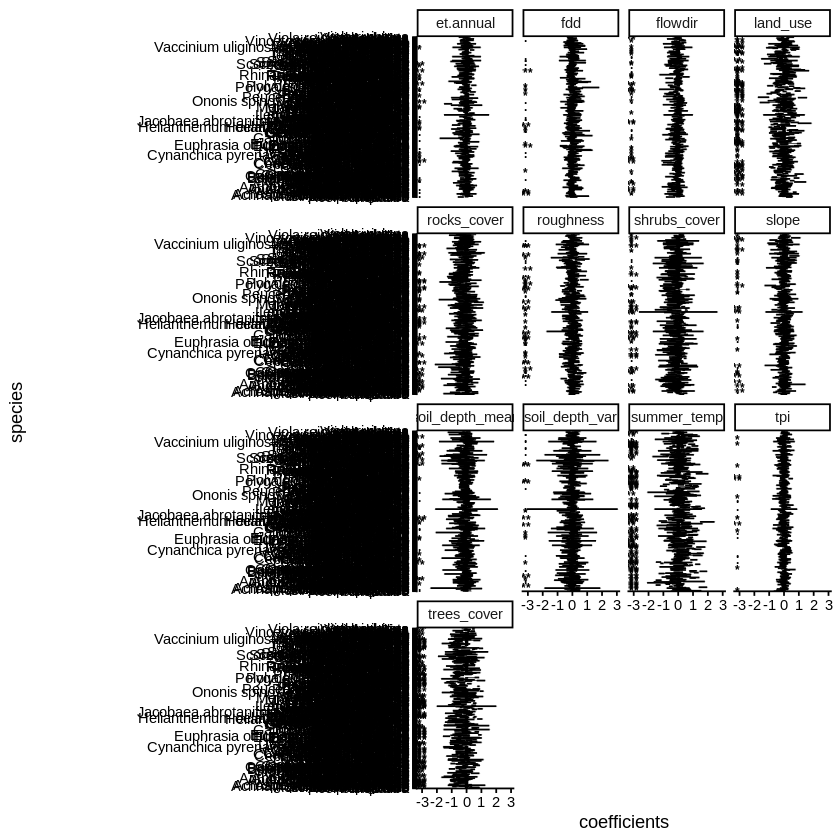

In [ ]:
plot(model)

In [ ]:
model = readRDS(file ="/content/drive/MyDrive/A_ETH/Calanda_JSDM/model_sjsdm_calanda_gpu_collab.rds")

In [ ]:
R2 = Rsquared(model, verbose = TRUE)
print(R2)
saveRDS(R2, file = "/content/drive/MyDrive/A_ETH/Calanda_JSDM/R2_sjsdm_calanda_gpu_collab.rds")

[1] 0.3782948
[1] 0.3782948


In [ ]:
an = anova(model, verbose = TRUE, samples = sampling)
saveRDS(an, file = "/content/drive/MyDrive/A_ETH/Calanda_JSDM/an_sjsdm_calanda_gpu_collab.rds")

In [ ]:
res = internalStructure(an, fractions = "proportional")

In [ ]:
saveRDS(R2, file = "R2_sjsdm_calanda.rds")
saveRDS(an, file = "an_sjsdm_calanda.rds")
saveRDS(res, file = "res_sjsdm_calanda.rds")